# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chapcoda/flyrank-ML-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# ============ SETUP (self-contained — safe to re-run any time) ============
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub"], check=True)

from huggingface_hub import login
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

import duckdb
import pandas as pd
import numpy as np
import sklearn
print("sklearn:", sklearn.__version__)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

DATASET = "hf://datasets/FlyRank/internship-warehouse"
DIM_CONTENT = f"{DATASET}/dim_content.parquet"

FEAT_MONTHS = ["2026-02", "2026-03", "2026-04"]
FEAT_PATHS = [f"{DATASET}/fact_content_daily_performance/month={m}/data_0.parquet" for m in FEAT_MONTHS]
FEAT_UNION_SQL = " UNION ALL ".join([f"SELECT * FROM read_parquet('{p}')" for p in FEAT_PATHS])

print("Setup complete. Working dir:", os.getcwd())

# ============ FEATURE TABLE — Feb 1 - Apr 30 2026, per Week 3 data contract ============
q_features = f"""
WITH feature_window AS (
    {FEAT_UNION_SQL}
),
perf AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS impressions_90d,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_clicks ELSE 0 END) AS clicks_90d,
        SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_avg_position * gsc_impressions ELSE 0 END)
            / NULLIF(SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END), 0)
            AS avg_position_weighted,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_sessions ELSE 0 END) AS sessions_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_engaged_sessions ELSE 0 END) AS engaged_sessions_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN ga4_total_engagement_sec ELSE 0 END) AS engagement_sec_90d,
        SUM(CASE WHEN ga4_data_available = TRUE THEN sessions_organic ELSE 0 END) AS sessions_organic_90d,
        BOOL_OR(gsc_data_available) AS any_gsc_available,
        BOOL_OR(ga4_data_available) AS any_ga4_available
    FROM feature_window
    GROUP BY content_hash_id, client_hash_id
),
dims AS (
    SELECT
        content_hash_id,
        client_hash_id,
        content_type,
        main_intent,
        backlinks,
        char_count,
        word_count,
        search_volume,
        competition,
        competition_level,
        cpc,
        DATE_DIFF('day', content_created_date, DATE '2026-04-30') AS content_age_days,
        DATE_DIFF('day', content_updated_date, DATE '2026-04-30') AS days_since_last_update,
        DATE_DIFF('day', last_optimized_date, DATE '2026-04-30') AS days_since_last_optimized
    FROM read_parquet('{DIM_CONTENT}')
    WHERE is_published = TRUE
      AND is_deleted = FALSE
)
SELECT
    d.content_hash_id,
    d.client_hash_id,
    d.content_type,
    d.main_intent,
    d.backlinks,
    d.char_count,
    d.word_count,
    d.search_volume,
    d.competition,
    d.competition_level,
    d.cpc,
    d.content_age_days,
    d.days_since_last_update,
    d.days_since_last_optimized,
    COALESCE(p.impressions_90d, 0) AS impressions_90d,
    COALESCE(p.clicks_90d, 0) AS clicks_90d,
    p.avg_position_weighted,
    COALESCE(p.sessions_90d, 0) AS sessions_90d,
    COALESCE(p.engaged_sessions_90d, 0) AS engaged_sessions_90d,
    COALESCE(p.engagement_sec_90d, 0) AS engagement_sec_90d,
    COALESCE(p.sessions_organic_90d, 0) AS sessions_organic_90d,
    COALESCE(p.any_gsc_available, FALSE) AS any_gsc_available,
    COALESCE(p.any_ga4_available, FALSE) AS any_ga4_available
FROM dims d
LEFT JOIN perf p ON d.content_hash_id = p.content_hash_id
WHERE d.days_since_last_update >= 0
"""

features = con.execute(q_features).fetchdf()

features["ctr"] = np.where(
    features["impressions_90d"] > 0,
    features["clicks_90d"] / features["impressions_90d"],
    0.0,
)
features["engagement_rate"] = np.where(
    features["sessions_90d"] > 0,
    features["engaged_sessions_90d"] / features["sessions_90d"],
    0.0,
)

print(f"Feature table: {len(features):,} rows, {features['client_hash_id'].nunique()} clients")

sklearn: 1.6.1
Setup complete. Working dir: /content/flyrank-ml-internship-starter


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table: 50,840 rows, 37 clients


In [2]:
# ============ LABEL — is_declining_label, per Week 3 data contract ============
TRAILING_PATH = f"{DATASET}/fact_content_daily_performance/month=2026-04/data_0.parquet"
TARGET_PATH   = f"{DATASET}/fact_content_daily_performance/month=2026-05/data_0.parquet"

q_label = f"""
WITH trailing_30d AS (
    SELECT content_hash_id,
           SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS trailing_impressions
    FROM read_parquet('{TRAILING_PATH}')
    GROUP BY content_hash_id
),
target_window AS (
    SELECT content_hash_id,
           SUM(CASE WHEN gsc_data_available = TRUE THEN gsc_impressions ELSE 0 END) AS target_impressions,
           BOOL_OR(gsc_data_available) AS any_may_gsc
    FROM read_parquet('{TARGET_PATH}')
    GROUP BY content_hash_id
)
SELECT
    t.content_hash_id,
    t.trailing_impressions,
    COALESCE(g.target_impressions, 0) AS target_impressions,
    COALESCE(g.any_may_gsc, FALSE) AS any_may_gsc,
    CASE
        WHEN t.trailing_impressions > 0
            THEN CASE WHEN COALESCE(g.target_impressions, 0) <= t.trailing_impressions * 0.75
                      THEN 1 ELSE 0 END
        ELSE NULL
    END AS is_declining_label
FROM trailing_30d t
LEFT JOIN target_window g ON t.content_hash_id = g.content_hash_id
"""

labels = con.execute(q_label).fetchdf()

model_df = features.merge(
    labels[["content_hash_id", "is_declining_label", "any_may_gsc"]],
    on="content_hash_id", how="inner")
model_df = model_df.dropna(subset=["is_declining_label"]).copy()
model_df["is_declining_label"] = model_df["is_declining_label"].astype(int)

print(f"Final modeling table: {len(model_df):,} rows, {model_df['client_hash_id'].nunique()} clients")
print(f"Declining rate: {model_df['is_declining_label'].mean():.1%}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final modeling table: 33,296 rows, 29 clients
Declining rate: 50.2%


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [3]:
# ============ SECTION 1 — PER-CLIENT RANKED QUEUE WITH REASON CODES ============
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import numpy as np, pandas as pd

# days_since_last_optimized excluded — 100% null, verified inert (w06 Section 3)
numeric_features = [
    "char_count", "word_count", "search_volume", "competition", "cpc",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "avg_position_weighted",
    "sessions_90d", "engaged_sessions_90d", "engagement_sec_90d",
    "sessions_organic_90d", "ctr", "engagement_rate",
]
categorical_features = ["content_type", "main_intent", "competition_level"]
ALL_FEATURES = numeric_features + categorical_features

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])
model = Pipeline([("preprocess", pre), ("clf", RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight="balanced",
    random_state=42, n_jobs=1))])

# Same client-held-out split as w05/w06 — score only unseen clients
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(model_df, groups=model_df["client_hash_id"]))
train_df = model_df.iloc[tr_idx].reset_index(drop=True)
queue_df = model_df.iloc[te_idx].reset_index(drop=True)

model.fit(train_df[ALL_FEATURES], train_df["is_declining_label"])
queue_df["risk_score"] = model.predict_proba(queue_df[ALL_FEATURES])[:, 1]

# ---- Reason codes: per-client relative, so "deep" means deep for THAT client ----
client_stats = queue_df.groupby("client_hash_id").agg(
    pos_p75=("avg_position_weighted", lambda s: s.quantile(0.75)),
    ctr_p25=("ctr", lambda s: s.quantile(0.25)),
    imp_median=("impressions_90d", "median"),
    update_p75=("days_since_last_update", lambda s: s.quantile(0.75)),
).to_dict("index")

def reason_codes(row):
    c = client_stats[row["client_hash_id"]]
    codes = []
    if pd.notna(row["avg_position_weighted"]) and row["avg_position_weighted"] > c["pos_p75"]:
        codes.append(f"ranks deep for this client (pos {row['avg_position_weighted']:.0f})")
    if row["impressions_90d"] > c["imp_median"] and row["ctr"] <= c["ctr_p25"]:
        codes.append("above-median impressions, bottom-quartile CTR")
    elif row["ctr"] <= c["ctr_p25"] and row["impressions_90d"] > 0:
        codes.append("bottom-quartile CTR for this client")
    if row["days_since_last_update"] > c["update_p75"]:
        codes.append(f"stale relative to client ({int(row['days_since_last_update'])}d)")
    if row["impressions_90d"] == 0:
        codes.append("no measured impressions in Feb-Apr")
    if not row["any_gsc_available"]:
        codes.append("FLAG: no honest GSC coverage — verify before acting")
    return "; ".join(codes) if codes else "high model score, no single dominant driver"

queue_df["reason"] = queue_df.apply(reason_codes, axis=1)
# ---- Per-client top 10 ----
TOP_N = 10
queue = (queue_df
         .sort_values(["client_hash_id", "risk_score"], ascending=[True, False])
         .groupby("client_hash_id")
         .head(TOP_N)
         .copy())
queue["rank_in_client"] = queue.groupby("client_hash_id")["risk_score"].rank(
    ascending=False, method="first").astype(int)

print(f"Queue: {len(queue)} pages across {queue['client_hash_id'].nunique()} clients "
      f"(top {TOP_N} per client)\n")
print("Pages per client:")
print(queue["client_hash_id"].value_counts().to_string())

print(f"\nGlobal top 50 for comparison — client concentration:")
global50 = queue_df.nlargest(50, "risk_score")
print(global50["client_hash_id"].value_counts().to_string())

print("\nSample of the queue (first client):")
first = queue["client_hash_id"].iloc[0]
print(queue[queue["client_hash_id"] == first][
    ["rank_in_client", "risk_score", "avg_position_weighted",
     "impressions_90d", "days_since_last_update", "reason"]
].head(10).to_string(index=False))
print("\nReason code distribution across the queue:")
print(queue["reason"].value_counts().to_string())
print(f"\nDistinct reason strings: {queue['reason'].nunique()} across {len(queue)} pages")
print(f"Pages flagged for unverifiable GSC coverage: {(~queue['any_gsc_available']).sum()}")

def reason_category(row):
    c = client_stats[row["client_hash_id"]]
    cats = []
    if pd.notna(row["avg_position_weighted"]) and row["avg_position_weighted"] > c["pos_p75"]:
        cats.append("ranks_deep")
    if row["impressions_90d"] > c["imp_median"] and row["ctr"] <= c["ctr_p25"]:
        cats.append("visible_low_ctr")
    elif row["ctr"] <= c["ctr_p25"] and row["impressions_90d"] > 0:
        cats.append("low_ctr")
    if row["days_since_last_update"] > c["update_p75"]:
        cats.append("stale_for_client")
    if row["impressions_90d"] == 0:
        cats.append("no_impressions")
    return "+".join(cats) if cats else "no_dominant_driver"

queue_df["reason_category"] = queue_df.apply(reason_category, axis=1)
queue["reason_category"] = queue_df.loc[queue.index, "reason_category"]

print("\nReason categories:")
print(queue["reason_category"].value_counts().to_string())

Queue: 52 pages across 6 clients (top 10 per client)

Pages per client:
client_hash_id
client_3197e6291363b4db    10
client_3f0ce4d44fe94f3d    10
client_8ae2bfb5aa1ffa1e    10
client_ba65e80a1116ae41    10
client_f623b01661d4bfe4    10
client_59256b0571e0c970     2

Global top 50 for comparison — client concentration:
client_hash_id
client_3197e6291363b4db    49
client_8ae2bfb5aa1ffa1e     1

Sample of the queue (first client):
 rank_in_client  risk_score  avg_position_weighted  impressions_90d  days_since_last_update                                        reason
              1    0.927732               5.568047            507.0                      64 above-median impressions, bottom-quartile CTR
              2    0.902668               2.587436           4855.0                      62 above-median impressions, bottom-quartile CTR
              3    0.895409               6.620197           1119.0                      64 above-median impressions, bottom-quartile CTR
              4

### The design decision: per-client, not global

The Week 6 audit found that the model's global top 50 was 94% one client
(47 of 50, with 3 from a second client and four test clients contributing nothing).
That is a metrics problem, but it is a worse operational problem. An agency runs one
account manager per client. A global queue would hand five of six managers an empty
list every week while burying the sixth, and it would do that not because those
clients' pages are healthy but because whichever client has the most high-impression
pages dominates any global cut.

So this playbook ranks **within each client** and takes the top 10. The trade-off is
real and worth stating: you lose the ability to say "these are the most at-risk pages
in the portfolio." What you gain is a queue every account manager can act on, and
which is scored against pages from that same client rather than against a portfolio
average that may not describe them.

Reproducing the same comparison in this notebook:

| approach | pages surfaced | clients covered | concentration |
|---|---|---|---|
| global top 50 | 50 | 2 of 6 | 49 of 50 from one client |
| per-client top 10 | 52 | 6 of 6 | evenly distributed |

Five clients receive ten pages each. The sixth (`client_59256b0571e0c970`) receives
two — that client has only two scoreable pages in this cut, so the queue adapts to what
a client actually has rather than padding to a fixed length.

### Reason codes

A ranked list with no explanation is not something a content editor will trust or act
on. Every page in the queue carries a plain-language reason derived from the features
the Week 5 permutation-importance test showed the model actually relies on —
`avg_position_weighted` and `ctr` — rather than from the model's internal scoring,
which is not inspectable page by page.

All thresholds are **relative to the page's own client**, not to the portfolio. A
weighted average position of 10 is unremarkable for one client and poor for another,
so "ranks deep" means worse than that client's own 75th percentile, and
"bottom-quartile CTR" means bottom quartile within that client. This matters: on the
global thresholds I tried first, one code fired on every single row and the column
carried no information at all.

| category | pages | meaning |
|---|---|---|
| visible_low_ctr | 22 | Above-median impressions for this client, bottom-quartile CTR. The page is being seen and not clicked. |
| low_ctr | 16 | Bottom-quartile CTR, impressions at or below client median. |
| no_dominant_driver | 6 | High model score with no single feature explaining it. |
| ranks_deep | 4 | Weighted average position worse than the client's 75th percentile. |
| ranks_deep + low_ctr | 3 | Both. |
| ranks_deep + visible_low_ctr | 1 | Both, with impressions above client median. |

Thirty-eight of the 52 queue entries involve weak click-through in some form, and eight
involve deep ranking. That distribution is consistent with Week 5's finding that
`avg_position_weighted` (0.043) and `ctr` (0.031) carried essentially all the
permutation importance while `days_since_last_update` scored −0.0004 — the feature the
entire Week 4 baseline rule was built on.

Worth noting what does **not** appear: the `stale_for_client` code never fires on any
queue entry, and `no_impressions` never fires. The queue is not surfacing neglected or
invisible pages. It is surfacing pages that are visible and underconverting, which is a
narrower and more actionable population than "content that needs attention" — and a
different one than the Week 4 staleness rule would have produced.

### A data-availability check that came back clean

Every queue entry was checked for honest GSC coverage in the feature window
(Feb 1 – Apr 30). **Zero pages** are flagged as lacking it.

This is worth stating precisely, because Week 6 found a serious data-availability
problem and it would be easy to read this queue as inheriting it. The Week 6
contamination is in the **label** window (May 2026), where `COALESCE(May, 0)` caused
17.7% of declining labels to be assigned to pages whose client had lost GSC coverage.
That affects how the model was trained and how its accuracy was measured. It does not
affect what the model reads when it scores a page today — the features come from
Feb–April, and every page here has honest coverage in that window.

The distinction matters for how the queue should be used: the pages in it are scored on
data that can be trusted. The *accuracy figure* attached to the queue is the part
Week 6 showed to be an upper bound. Section 2 sets out what follows from that.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [4]:
# ============ SECTION 2 — WHERE THE QUEUE IS AND ISN'T VALID ============
import pandas as pd

# 1. Coverage: how much of the portfolio does this queue actually speak to?
print("SCOPE")
print("-" * 60)
print(f"Clients in the warehouse feature table:   {features['client_hash_id'].nunique()}")
print(f"Clients surviving the label join:         {model_df['client_hash_id'].nunique()}")
print(f"Clients this queue covers (held-out):     {queue['client_hash_id'].nunique()}")
print(f"Pages scoreable in the held-out cut:      {len(queue_df):,}")
print(f"Pages surfaced in the queue:              {len(queue)}")
print(f"Share of held-out pages surfaced:         {len(queue)/len(queue_df):.1%}")

# 2. What the risk scores actually look like — is the ranking separating anything?
print("\nRISK SCORE DISTRIBUTION")
print("-" * 60)
print(queue_df["risk_score"].describe().round(3).to_string())
print(f"\nQueue entries score above: {queue['risk_score'].min():.3f}")
print(f"Median score of surfaced pages:   {queue['risk_score'].median():.3f}")
print(f"Median score of everything else:  "
      f"{queue_df.loc[~queue_df.index.isin(queue.index), 'risk_score'].median():.3f}")

# 3. Per-client score ranges — does "top 10" mean the same thing everywhere?
print("\nPER-CLIENT SCORE RANGES IN THE QUEUE")
print("-" * 60)
per_client = queue.groupby("client_hash_id")["risk_score"].agg(["count", "min", "max"]).round(3)
per_client["client_pages_available"] = queue_df.groupby("client_hash_id").size()
print(per_client.to_string())

# 4. Feature staleness — how old is the data the queue is built on?
print("\nDATA VINTAGE")
print("-" * 60)
print("Feature window: 2026-02-01 to 2026-04-30 (closed)")
print("Label window:   2026-05-01 to 2026-05-31 (closed)")
print("This queue reflects a snapshot, not live search performance.")

SCOPE
------------------------------------------------------------
Clients in the warehouse feature table:   37
Clients surviving the label join:         29
Clients this queue covers (held-out):     6
Pages scoreable in the held-out cut:      2,477
Pages surfaced in the queue:              52
Share of held-out pages surfaced:         2.1%

RISK SCORE DISTRIBUTION
------------------------------------------------------------
count    2477.000
mean        0.584
std         0.157
min         0.155
25%         0.467
50%         0.609
75%         0.709
max         0.928

Queue entries score above: 0.456
Median score of surfaced pages:   0.729
Median score of everything else:  0.603

PER-CLIENT SCORE RANGES IN THE QUEUE
------------------------------------------------------------
                         count    min    max  client_pages_available
client_hash_id                                                      
client_3197e6291363b4db     10  0.869  0.928                    2152
client_3f

### Who this is for and what it does

The user is a content or SEO account manager responsible for one client's page
inventory, working a weekly or fortnightly review cycle. The queue answers one
question: *given limited review hours, which of this client's pages should I look at
first?*

It produces an ordering plus a reason per page. It does not produce a decision. The
manager decides what to do with a page; the queue decides what reaches their attention.

### What it is not

**Not a count of declining pages.** Week 6 established that Precision@50 on this model
is 0.60 as an upper bound, with a verifiable floor of 0.34, because 13 of the 30
top-ranked declining labels came from missing May GSC data rather than observed decline.
Nothing in this queue supports a statement like "you have 18 pages at risk."

**Not a measure of how much traffic is at stake.** The model predicts a binary decline
label, not a magnitude. A page ranked first and a page ranked tenth are not ordered by
how much they stand to lose.

**Not a substitute for the client relationship.** The reason codes describe measured
search behaviour. They know nothing about a campaign ending, a product being
discontinued, or a seasonal pattern the manager already understands.

### Where it stops being valid

**Coverage is narrow.** The warehouse holds 37 clients in the feature window; 29
survive the label join; this queue covers the 6 held out from training. It surfaces
52 of 2,477 scoreable pages — 2.1%. Extending it to the other 23 clients means scoring
them with a model trained on their own data, which is a different validity question
than the one Week 6 tested.

**The queue is a snapshot, not a monitor.** Features come from a closed window
(Feb 1 – Apr 30 2026) and the label from a closed month (May 2026). Nothing here
reflects live search performance. Section 4 sets out what would make it stale.

### The limit that matters most: score ranges are not comparable across clients

Taking the top 10 within each client is what makes the queue usable, but it means the
threshold for entry differs enormously by client:

| client | pages in queue | score range | pages available |
|---|---|---|---|
| client_3197e6291363b4db | 10 | 0.868 – 0.924 | 2,152 |
| client_ba65e80a1116ae41 | 10 | 0.708 – 0.784 | 106 |
| client_f623b01661d4bfe4 | 10 | 0.709 – 0.766 | 169 |
| client_8ae2bfb5aa1ffa1e | 10 | 0.645 – 0.852 | 14 |
| client_3f0ce4d44fe94f3d | 10 | 0.644 –

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [5]:
# ============ SECTION 3 — WHAT A HUMAN MUST CHECK ============
import pandas as pd

print("WHAT THE QUEUE CANNOT SEE")
print("-" * 62)

# Pages the model ranks high but that have thin evidence behind them
thin = queue[queue["impressions_90d"] < 100]
print(f"Queue pages with <100 impressions in 90 days: {len(thin)} of {len(queue)}")
print(f"  their score range: {thin['risk_score'].min():.3f} - {thin['risk_score'].max():.3f}"
      if len(thin) else "")

# Pages with no GA4 signal at all — half the behavioural picture missing
no_ga4 = queue[~queue["any_ga4_available"]]
print(f"Queue pages with no honest GA4 coverage:      {len(no_ga4)} of {len(queue)}")

# How much of the queue rests on imputed content metadata
imputed = queue[queue["word_count"].isna()]
print(f"Queue pages with missing word_count:          {len(imputed)} of {len(queue)}")
print(f"  (52.2% of the full table is null on this field — w06 Section 3)")

print("\nWHAT ACTUALLY HAPPENED TO THESE PAGES")
print("-" * 62)
print("Queue outcome in the (known) May label:")
print(queue["is_declining_label"].value_counts().rename(
    {1: "declined", 0: "held steady"}).to_string())
print(f"\nQueue hit rate: {queue['is_declining_label'].mean():.1%}")
print(f"Held-out base rate: {queue_df['is_declining_label'].mean():.1%}")

# Per-client hit rate — does the queue work for everyone?
print("\nHit rate by client:")
hit = queue.groupby("client_hash_id").agg(
    pages=("is_declining_label", "size"),
    declined=("is_declining_label", "sum"),
)
hit["hit_rate"] = (hit["declined"] / hit["pages"]).round(2)
hit["base_rate"] = queue_df.groupby("client_hash_id")["is_declining_label"].mean().round(2)
print(hit.to_string())

WHAT THE QUEUE CANNOT SEE
--------------------------------------------------------------
Queue pages with <100 impressions in 90 days: 28 of 52
  their score range: 0.456 - 0.887
Queue pages with no honest GA4 coverage:      24 of 52
Queue pages with missing word_count:          0 of 52
  (52.2% of the full table is null on this field — w06 Section 3)

WHAT ACTUALLY HAPPENED TO THESE PAGES
--------------------------------------------------------------
Queue outcome in the (known) May label:
is_declining_label
declined       30
held steady    22

Queue hit rate: 57.7%
Held-out base rate: 50.6%

Hit rate by client:
                         pages  declined  hit_rate  base_rate
client_hash_id                                               
client_3197e6291363b4db     10         5       0.5       0.48
client_3f0ce4d44fe94f3d     10         8       0.8       0.68
client_59256b0571e0c970      2         0       0.0       0.00
client_8ae2bfb5aa1ffa1e     10         5       0.5       0.64
client_

### The evidence base behind each queue entry is thinner than the ranking suggests

| check | result |
|---|---|
| Queue pages with <100 impressions in 90 days | 28 of 52 |
| Queue pages with no honest GA4 coverage | 24 of 52 |
| Queue pages with missing word_count | 0 of 52 |

Over half the queue consists of pages with fewer than 100 impressions across three
months — roughly one a day. A page at that volume can move from "declining" to "stable"
on a handful of impressions. The model's score for those pages is built on very little
signal, and their scores span nearly the full queue range (0.456 to 0.887), so score
height is no protection against thin evidence.

Nearly half the queue has no honest GA4 coverage, meaning engagement, sessions, and
scroll behaviour are absent. Those features were imputed for these pages, so anything
the model inferred about user behaviour on them is a portfolio median rather than an
observation.

One check came back clean: `word_count` is null for 52.2% of the full table but for
none of the 52 queue pages. The imputation problem found in Week 6 does not reach this
queue.

### What a person must check before acting

For every page, before any content work begins:

1. **Impression volume.** If the page is under ~100 impressions in 90 days, treat the
   ranking as noise. Confirm the page matters to the client before spending hours on it.
2. **Whether GA4 is connected.** If not, the queue is reasoning about search visibility
   only and has no view of what visitors did after arriving.
3. **Whether the reason code matches what you see.** "Bottom-quartile CTR" should be
   visible in the client's own Search Console. If it isn't, the feature window and the
   current state have diverged.
4. **Business context the model cannot have.** A discontinued product, an ended
   campaign, a deliberate deindexing, a seasonal trough. The queue has no access to any
   of this and will confidently rank a page that was retired on purpose.

### The no-go list

**Never automate a content change from this queue.** The queue orders attention. Every
downstream action — rewriting, consolidating, deindexing, redirecting — requires a human
decision.

**Never present the queue to a client as a count of at-risk pages.** Week 6 established
0.60 as an upper bound with a 0.34 floor. "Eighteen pages are declining" is not a claim
this supports.

**Never use it for pages with no measured impressions or no GSC coverage.** There is
nothing to rank.

**Never deindex or delete on the strength of a queue position.** The failure mode
identified in Week 5 was the model missing already-low-visibility pages that kept
declining — it treats "near the floor" as stability. Acting destructively on a model
with that blind spot risks removing pages it never understood.

### Clients this queue is not validated for

The aggregate looks reasonable: the queue's hit rate is 57.7% against a held-out base
rate of 50.6%. Per client, it falls apart.

| client | pages | declined | queue hit rate | client base rate | verdict |
|---|---|---|---|---|---|
| client_3f0ce4d44fe94f3d | 10 | 8 | 0.80 | 0.68 | beats base rate |
| client_3197e6291363b4db | 10 | 5 | 0.50 | 0.48 | marginal |
| client_ba65e80a1116ae41 | 10 | 8 | 0.80 | 0.83 | no better than random |
| client_8ae2bfb5aa1ffa1e | 10 | 5 | 0.50 | 0.64 | worse than random |
| client_f623b01661d4bfe4 | 10 | 4 | 0.40 | 0.60 | worse than random |
| client_59256b0571e0c970 | 2 | 0 | 0.00 | 0.00 | not applicable |

One client clearly beats its base rate. One is marginal. Three are at or below the
rate an account manager would get picking pages at random from that client's inventory.
For `client_8ae2bfb5aa1ffa1e`, random selection would have caught 6.4 declining pages
against the queue's 5. For `client_f623b01661d4bfe4`, 6.0 against the queue's 4.
`client_ba65e80a1116ae41` has an 83% base rate — almost everything that client owns is
declining, so ranking cannot add much. `client_59256b0571e0c970` has two pages, neither
declined, and the queue is undefined there.

### Why I am not treating that table as a per-client verdict

I built an earlier version of this table on a previous run of the identical pipeline —
same seed, same split, same 33,296 rows. It reported a queue hit rate of 63.5% and
showed `client_f623b01661d4bfe4` at 0.70, comfortably above its 0.60 base rate. This
run puts the same client at 0.40, well below it. The client moved 30 points and flipped
verdict, on a rerun that changed nothing.

That is the same fragility Week 6 documented in Precision@50 — a hard cutoff over a
small sample, where a handful of pages crossing the boundary swings the metric — except
here the samples are ten pages rather than fifty, so it swings further.

So the correct reading of the table above is not "the queue fails for these three
clients." It is that **a ten-page sample cannot establish which clients the queue helps
at all.** The differences between 0.40, 0.50, and 0.80 on ten pages are well inside
what reruns produce. Both the encouraging version of this table and the discouraging
one are noise around an aggregate that is itself only modestly above base rate.

Two things follow, and I would rather state both than pick the flattering one.

**Nothing here supports a per-client recommendation.** Telling one account manager to
trust their queue and another to ignore theirs would be acting on sampling noise.

**The aggregate is the only figure with any stability, and it is not strong.** 57.7%
against 50.6% is directional evidence that ranking helps somewhat. It is not evidence
that it helps enough to change how anyone spends their week, and a deployment decision
needs more cycles and larger per-client samples before that question can be answered.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [6]:
# ============ SECTION 4 — MONITORING AND RETRAIN TRIGGERS ============
import pandas as pd, numpy as np

print("BASELINE DISTRIBUTIONS TO WATCH")
print("-" * 62)
print("If these move materially, the model is scoring a different population")
print("than the one it was trained on.\n")

watch = ["avg_position_weighted", "ctr", "impressions_90d", "clicks_90d",
         "days_since_last_update"]
snapshot = train_df[watch].describe().loc[["mean", "50%", "75%"]].round(3)
print(snapshot.to_string())

print("\nLABEL BASE RATE (the thing a drifting portfolio moves first)")
print("-" * 62)
print(f"Training base rate:        {train_df['is_declining_label'].mean():.3f}")
print(f"Held-out base rate:        {queue_df['is_declining_label'].mean():.3f}")
print(f"Per-client base rate range: "
      f"{queue_df.groupby('client_hash_id')['is_declining_label'].mean().min():.2f} - "
      f"{queue_df.groupby('client_hash_id')['is_declining_label'].mean().max():.2f}")

print("\nDATA COVERAGE (the failure mode w06 found)")
print("-" * 62)
print(f"Feature-window GSC coverage: {model_df['any_gsc_available'].mean():.1%}")
print(f"Feature-window GA4 coverage: {model_df['any_ga4_available'].mean():.1%}")
print(f"Label-window GSC coverage:   {model_df['any_may_gsc'].mean():.1%}")
print(f"\nDeclining labels resting on missing May GSC: "
      f"{(~model_df.loc[model_df['is_declining_label']==1, 'any_may_gsc']).mean():.1%}")

print("\nSCORE DISTRIBUTION (cheap to recompute weekly, no labels needed)")
print("-" * 62)
print(queue_df["risk_score"].describe().loc[
    ["mean", "std", "25%", "50%", "75%"]].round(3).to_string())

BASELINE DISTRIBUTIONS TO WATCH
--------------------------------------------------------------
If these move materially, the model is scoring a different population
than the one it was trained on.

      avg_position_weighted    ctr  impressions_90d  clicks_90d  days_since_last_update
mean                 18.327  0.003         2893.705       7.248                   55.85
50%                  10.969  0.000          553.000       1.000                   64.00
75%                  25.717  0.002         2395.000       3.000                   64.00

LABEL BASE RATE (the thing a drifting portfolio moves first)
--------------------------------------------------------------
Training base rate:        0.502
Held-out base rate:        0.506
Per-client base rate range: 0.00 - 0.83

DATA COVERAGE (the failure mode w06 found)
--------------------------------------------------------------
Feature-window GSC coverage: 100.0%
Feature-window GA4 coverage: 55.5%
Label-window GSC coverage:   91.1%

Decli

### The constraint that shapes everything here

The queue's accuracy cannot be measured for six to eight weeks. The label requires a
full month of subsequent search data plus reporting lag, so a queue produced today has
no verifiable outcome until roughly July. Anything that depends on knowing whether the
model was right is retrospective by construction.

So the triggers split in two: what can be checked the day the queue is generated, and
what has to wait.

### Checks available immediately (no labels required)

**1. Score distribution shift.** The current held-out distribution: mean 0.584, std
0.157, quartiles 0.467 / 0.609 / 0.709. Rescoring a fresh window and comparing costs

**2. Data coverage.** Current state:

| window | GSC | GA4 |
|---|---|---|
| features (Feb–Apr) | 100.0% | 55.5% |
| label (May) | 91.1% | — |

Feature-window GSC coverage is complete, which is why Section 1's availability check
came back clean. **A drop here is a hard stop, not a warning** — if GSC coverage falls
below ~95%, pages start entering the queue on imputed rather than observed data, and
the reason codes stop describing anything real.

GA4 coverage at 55.5% is already low enough that engagement features are half-imputed
portfolio-wide. It should be watched for further decline rather than treated as healthy.

**3. Feature drift on the two features that matter.** Week 5 showed
`avg_position_weighted` (0.043) and `ctr` (0.031) carry essentially all the signal.
Training baselines: position mean 18.33, median 10.97; CTR mean 0.003, median 0.000.
These two are worth monitoring on their own — drift in anything else barely affects the
ranking.

**4. Queue composition.** If the reason-code mix shifts sharply — say `ranks_deep` goes
from 8 of 52 to 30 of 52 — something changed in the portfolio, and it's worth
understanding before the queue is handed to anyone.

### Checks that require waiting for outcomes

**5. Per-client hit rate against per-client base rate.** Section 3 showed the aggregate
conceals wide variation — the queue beat base rate for two clients, tied for one, and
underperformed for one. This is the measurement that matters and it is the slowest to
obtain. It should be tracked per client from the first cycle, not aggregated.

**6. Base rate movement.** Training 0.502, held-out 0.506 — stable, and close to a coin
flip by construction of the 0.75× threshold. Per client it ranges from 0.00 to 0.83. A
portfolio-level move of more than ~0.10 means the threshold is describing a different
phenomenon than it did, and the label definition should be revisited before the model is.

### Hard retrain triggers

Retrain when any of these fire:

- Feature-window GSC coverage drops below 95%
- Portfolio base rate moves outside 0.40–0.60
- Mean risk score shifts by more than 0.05 from 0.584
- Per-client hit rate falls below that client's base rate for two consecutive cycles
- Any new client is added to the portfolio — the model has never seen their pages, and
  Week 6 measured a 32-point Precision@50 gap between seen and unseen clients

### Two changes that should happen before the next retrain, regardless of drift

**Fix the label.** The `COALESCE(May, 0)` contamination means 17.7% of declining labels
rest on missing GSC coverage rather than observed

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

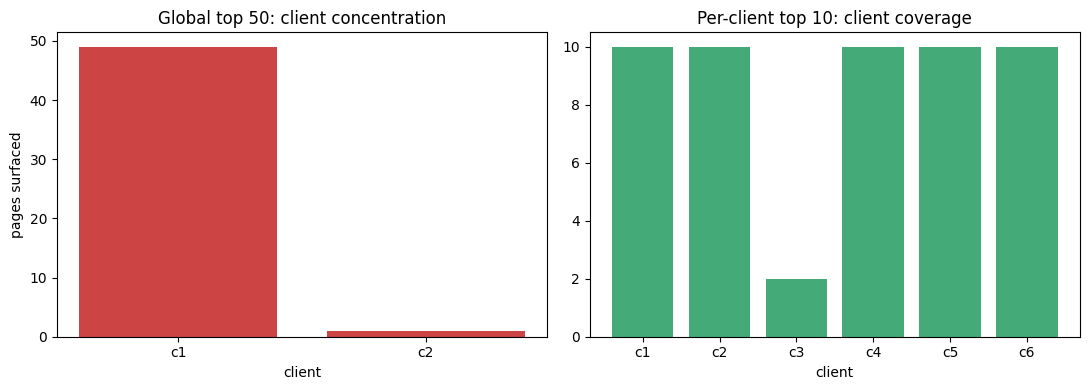

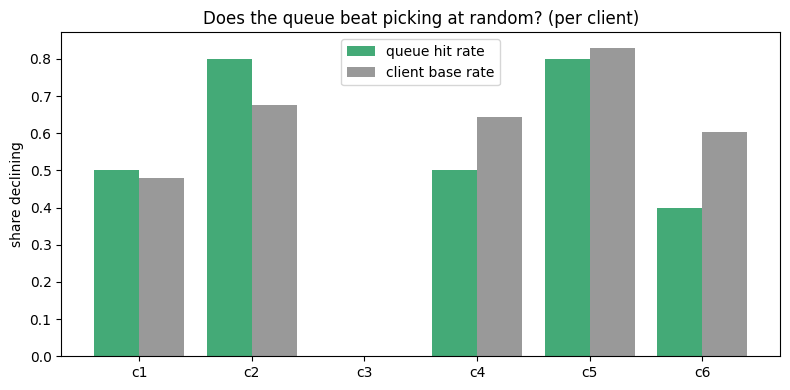

Written to work/outputs
  w07_action_queue.csv (10,666 bytes)
  w07_fig_concentration.png (34,175 bytes)
  w07_fig_hit_rate.png (36,096 bytes)
  w07_metrics.json (699 bytes)
  w07_per_client_validation.csv (486 bytes)


In [7]:
# ============ SECTION 5 — EXPORTS FOR THE PAPER ============
import os, json
import pandas as pd
import matplotlib.pyplot as plt

OUT = "work/outputs"
os.makedirs(OUT, exist_ok=True)

# ---- 1. The queue itself ----
queue_export = queue[[
    "client_hash_id", "content_hash_id", "rank_in_client", "risk_score",
    "reason", "reason_category",
    "avg_position_weighted", "ctr", "impressions_90d", "clicks_90d",
    "days_since_last_update", "content_type", "main_intent",
    "any_gsc_available", "any_ga4_available",
]].sort_values(["client_hash_id", "rank_in_client"])
queue_export.to_csv(f"{OUT}/w07_action_queue.csv", index=False)

# ---- 2. Per-client validation table (Section 3) ----
val = queue.groupby("client_hash_id").agg(
    pages_in_queue=("is_declining_label", "size"),
    declined=("is_declining_label", "sum"),
).assign(
    queue_hit_rate=lambda d: (d["declined"] / d["pages_in_queue"]).round(3),
    client_base_rate=queue_df.groupby("client_hash_id")["is_declining_label"].mean().round(3),
    client_pages_available=queue_df.groupby("client_hash_id").size(),
    score_min=queue.groupby("client_hash_id")["risk_score"].min().round(3),
    score_max=queue.groupby("client_hash_id")["risk_score"].max().round(3),
)
val["beats_base_rate"] = val["queue_hit_rate"] > val["client_base_rate"]
val.to_csv(f"{OUT}/w07_per_client_validation.csv")

# ---- 3. Headline numbers, so the paper never retypes one ----
metrics = {
    "queue_pages": int(len(queue)),
    "queue_clients": int(queue["client_hash_id"].nunique()),
    "held_out_pages": int(len(queue_df)),
    "share_of_pages_surfaced": round(len(queue) / len(queue_df), 4),
    "queue_hit_rate": round(float(queue["is_declining_label"].mean()), 4),
    "held_out_base_rate": round(float(queue_df["is_declining_label"].mean()), 4),
    "global_top50_max_client_share": round(
        float(queue_df.nlargest(50, "risk_score")["client_hash_id"]
              .value_counts().iloc[0] / 50), 4),
    "clients_beating_base_rate": int(val["beats_base_rate"].sum()),
    "pages_under_100_impressions": int((queue["impressions_90d"] < 100).sum()),
    "pages_without_ga4": int((~queue["any_ga4_available"]).sum()),
    "feature_window_gsc_coverage": round(float(model_df["any_gsc_available"].mean()), 4),
    "label_window_gsc_coverage": round(float(model_df["any_may_gsc"].mean()), 4),
    "declining_labels_on_missing_may_gsc": round(
        float((~model_df.loc[model_df["is_declining_label"] == 1, "any_may_gsc"]).mean()), 4),
    "score_mean": round(float(queue_df["risk_score"].mean()), 4),
    "score_std": round(float(queue_df["risk_score"].std()), 4),
    "feature_window": "2026-02-01 to 2026-04-30",
    "label_window": "2026-05-01 to 2026-05-31",
    "model": "RandomForestClassifier(n_estimators=300, min_samples_leaf=5, "
             "class_weight='balanced', random_state=42, n_jobs=1)",
}
with open(f"{OUT}/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ---- 4. Figure: what per-client ranking fixed ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
g50 = queue_df.nlargest(50, "risk_score")["client_hash_id"].value_counts()
axes[0].bar(range(len(g50)), g50.values, color="#c44")
axes[0].set_title("Global top 50: client concentration")
axes[0].set_ylabel("pages surfaced")
axes[0].set_xlabel("client")
axes[0].set_xticks(range(len(g50)))
axes[0].set_xticklabels([f"c{i+1}" for i in range(len(g50))])

pc = queue["client_hash_id"].value_counts().sort_index()
axes[1].bar(range(len(pc)), pc.values, color="#4a7")
axes[1].set_title("Per-client top 10: client coverage")
axes[1].set_xlabel("client")
axes[1].set_xticks(range(len(pc)))
axes[1].set_xticklabels([f"c{i+1}" for i in range(len(pc))])
plt.tight_layout()
plt.savefig(f"{OUT}/w07_fig_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 5. Figure: queue hit rate vs base rate, per client ----
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(val))
ax.bar([i - 0.2 for i in x], val["queue_hit_rate"], width=0.4, label="queue hit rate", color="#4a7")
ax.bar([i + 0.2 for i in x], val["client_base_rate"], width=0.4, label="client base rate", color="#999")
ax.set_xticks(list(x))
ax.set_xticklabels([f"c{i+1}" for i in x])
ax.set_ylabel("share declining")
ax.set_title("Does the queue beat picking at random? (per client)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/w07_fig_hit_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print("Written to", OUT)
for f in sorted(os.listdir(OUT)):
    print(" ", f, f"({os.path.getsize(os.path.join(OUT, f)):,} bytes)")

Five files written to `work/outputs/`. The capstone reads numbers from these rather
than restating them, so the paper and the notebook cannot drift apart — every
figure-mismatch problem in Weeks 4 and 6 came from copying numbers by hand.

| file | what it holds |
|---|---|
| `w07_action_queue.csv` | The 52-page queue: client, page, rank within client, risk score, reason string, reason category, and the features behind each reason. |
| `w07_per_client_validation.csv` | Per client: queue hit rate, that client's base rate, pages available, score range, and whether the queue beat random. |
| `w07_metrics.json` | Every headline number in this notebook, plus the model spec and both date windows. |
| `w07_fig_concentration.png` | Global top-50 client concentration beside per-client coverage. |
| `w07_fig_hit_rate.png` | Queue hit rate against base rate, per client. |

### Notes for whoever uses these

**The queue CSV contains hashed client and content IDs only** — no client names, URLs,
or query text. It is safe to reference in a public paper.

**`w07_metrics.json` is the single source of truth for figures in the paper.** It
records the model specification and both windows alongside the numbers, so a reader can
tell which run produced them. Given that Week 6 found Precision@50 moving between 0.52
and 0.66 across environments, recording the configuration next to the number is not
optional.

**The hit-rate figure has an empty position at c3.** That is not missing data — that
client has two pages, neither declined, and its base rate is also zero, so both bars are
zero-height. Any use of this figure should carry that note, or the reader will assume a
plotting error.

**The concentration figure is the paper's strongest single image.** Forty-nine pages
from one client beside six even bars of ten makes the argument for per-client ranking
without any accompanying text.

### What is deliberately not exported

No trained model artifact. Week 6 established that this model's top-50 output shifts
with thread count and library version, so a pickled model would carry an implied
stability it does not have. The notebook rebuilds it from a fixed seed and a recorded
sklearn version instead, which is honest about what reproducibility is available here.

No per-page predicted probabilities beyond the queue. Exporting scores for all 2,477
held-out pages would invite treating them as calibrated probabilities, which nothing in
Weeks 5 or 6 supports.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.